In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import plotly.express as px

from pull_data import load_draft_dataframe

In [23]:
draft_id = 522458773321240576
url = f'https://api.sleeper.app/v1/draft/{draft_id}/picks'

response = requests.get(url)

print(response.status_code) #- prints 200
# print(response.json())

picks = response.json()
# print(picks[0]) - look for 'roster_id' in both outputs -> use that to link pick number and total points acquired
# for pick in picks:
#     print(pick['metadata']['first_name'], pick['metadata']['last_name'], pick['metadata']['position'])

league_id = 522458773317046272

url2 = f'https://api.sleeper.app/v1/league/{league_id}/rosters'
response2 = requests.get(url2)
print(response2.status_code) #- prints 200

rosters = response2.json()
# print(rosters[0]) - look for 'roster_id' in both outputs -> use that to link pick number and total points acquired

# fpts: actual points the team got in total
# ppts: highest total score a team could have gotten if the team had their highest scoring team in each week

roster_points = {}
for roster in rosters:
    r_id = roster["roster_id"]
    points = roster["settings"]["fpts"]
    roster_points[r_id] = points

rows = []
for pick in picks:
    r_id = pick["roster_id"]
    player_name = pick["metadata"]["first_name"] + " " + pick["metadata"]["last_name"]
    position = pick["metadata"]["position"]
    pick_no = pick["pick_no"]
    round_no = pick['round']
    pick_number = pick['pick_no']
    team_points = roster_points.get(r_id, None)

    rows.append({
        "pick_no": pick_no,
        "round": round_no,
        "player": player_name,
        "position": position,
        "roster_id": r_id,
        "team_points": team_points
    })

for row in rows:
    print(f"{row['player']}: Round {row['round']}, Pick: {row['pick_no']}")

200
200
Clyde Edwards-Helaire: Round 1, Pick: 1
Jonathan Taylor: Round 1, Pick: 2
J.K. Dobbins: Round 1, Pick: 3
Jerry Jeudy: Round 1, Pick: 4
Cam Akers: Round 1, Pick: 5
D'Andre Swift: Round 1, Pick: 6
CeeDee Lamb: Round 1, Pick: 7
Justin Jefferson: Round 1, Pick: 8
Jalen Reagor: Round 1, Pick: 9
Henry Ruggs III: Round 1, Pick: 10
Tee Higgins: Round 1, Pick: 11
Denzel Mims: Round 1, Pick: 12
Ke'Shawn Vaughn: Round 2, Pick: 13
Laviska Shenault: Round 2, Pick: 14
Brandon Aiyuk: Round 2, Pick: 15
K.J. Hamler: Round 2, Pick: 16
Michael Pittman: Round 2, Pick: 17
Bryan Edwards: Round 2, Pick: 18
Zack Moss: Round 2, Pick: 19
A.J. Dillon: Round 2, Pick: 20
Antonio Gibson: Round 2, Pick: 21
Joshua Kelley: Round 2, Pick: 22
Chase Claypool: Round 2, Pick: 23
Tua Tagovailoa: Round 2, Pick: 24
Joe Burrow: Round 3, Pick: 25
Anthony McFarland: Round 3, Pick: 26
Darrynton Evans: Round 3, Pick: 27
Devin Duvernay: Round 3, Pick: 28
Van Jefferson: Round 3, Pick: 29
Donovan Peoples-Jones: Round 3, Pick:

In [18]:
# Start of the analysis

df = pd.DataFrame(rows)
print(df.head())
print(df.shape)

   pick_no  round                 player position  roster_id  team_points
0        1      1  Clyde Edwards-Helaire       RB          4         1440
1        2      1        Jonathan Taylor       RB          5         1280
2        3      1           J.K. Dobbins       RB         11         1414
3        4      1            Jerry Jeudy       WR          2          887
4        5      1              Cam Akers       RB          8         1185
(48, 6)


In [19]:
df = df.dropna(subset = ['team_points'])

# does higher pick number correspond to a higher amount of points
correlation = df['pick_no'].corr(df['team_points'])
print('Correlation between pick number and total team points:', round(correlation, 5))

# average team points by round
round_avg = df.groupby('round')['team_points'].mean()
print(round_avg)

# average team points based on position drafted
position_avg = df.groupby('position')['team_points'].mean().sort_values(ascending=False)
print(position_avg)

Correlation between pick number and total team points: 0.37766
round
1    1095.166667
2    1338.750000
3    1331.833333
4    1301.333333
Name: team_points, dtype: float64
position
TE    1359.666667
RB    1311.000000
QB    1290.200000
WR    1224.400000
Name: team_points, dtype: float64


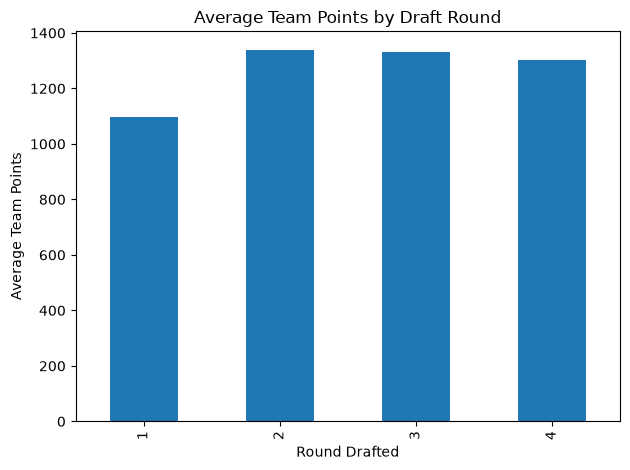

In [20]:
# Beginning of Visualizations

round_avg.plot(kind = 'bar', title = 'Average Team Points by Draft Round')
plt.xlabel('Round Drafted')
plt.ylabel('Average Team Points')
plt.tight_layout()
plt.show()

In [21]:
# plt.scatter(df['pick_no'], df['team_points'])
# plt.xlabel('Pick Number')
# plt.ylabel('Team Points')
# plt.title("Draft Pick Number vs. Total Team Points")
# plt.tight_layout()
# plt.show()

fig = px.scatter(df, x='pick_no', y='team_points', hover_data=['player'])
fig.update_layout(
    title="Draft Pick Number vs. Total Team Points")
fig.show()